In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =====================================
# 📘 Linear SVM Classification with ADASYN-SMOTE
# =====================================

import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import ADASYN
from collections import Counter
import os

os.environ['OMP_NUM_THREADS'] = str(os.cpu_count())
print(f"💻 Using CPU Threads: {os.cpu_count()}")

💻 Using CPU Threads: 2


In [3]:
# =======================
# === Block 1: Load Data
# =======================
train_path = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/train_split.csv"
test_path  = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/test_split.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print("✅ Data Loaded Successfully!")
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)


✅ Data Loaded Successfully!
Train shape: (329623, 13)
Test shape: (82406, 13)


In [4]:
# ==============================
# === Block 2: Split Features
# ==============================
target_col = "PM2.5_level"
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]
X_test  = df_test.drop(columns=[target_col])
y_test  = df_test[target_col]

In [5]:
# =====================================
# === Block 3: Apply ADASYN-SMOTE
# =====================================
print("\nBefore ADASYN-SMOTE:", Counter(y_train))
adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train)
print("\nAfter ADASYN-SMOTE:", Counter(y_resampled))



Before ADASYN-SMOTE: Counter({5: 128801, 4: 73062, 1: 64314, 2: 33504, 3: 29942})

After ADASYN-SMOTE: Counter({2: 135406, 1: 132707, 3: 130319, 5: 128801, 4: 122929})


In [6]:
# ===========================================
# === Block 4: 10-Fold Cross Validation (Train) + Mean ± SD
# ===========================================
import os

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []
accuracy_list, precision_list, recall_list, f1_list, auc_scores = [], [], [], [], []

print("\n=== 10-Fold Cross Validation Results ===")

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_resampled, y_resampled), 1):
    X_tr, X_val = X_resampled.iloc[train_idx], X_resampled.iloc[val_idx]
    y_tr, y_val = y_resampled.iloc[train_idx], y_resampled.iloc[val_idx]

    model = LinearSVC()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

    # AUC (One-vs-Rest)
    y_val_bin = label_binarize(y_val, classes=sorted(y_resampled.unique()))
    y_pred_bin = label_binarize(y_pred, classes=sorted(y_resampled.unique()))
    auc_val = roc_auc_score(y_val_bin, y_pred_bin, average='macro', multi_class='ovr')

    print(f"Fold {fold}: Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, "
          f"F1={f1:.3f}, AUC={auc_val:.3f}")

    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    auc_scores.append(auc_val)
    results.append([fold, acc, prec, rec, f1, auc_val])

# === แสดงผลแบบตาราง ===
cv_df = pd.DataFrame(results, columns=["Fold", "Accuracy", "Precision", "Recall", "F1", "AUC_ROC"])
print("\n" + cv_df.to_string(index=False))

# === คำนวณ Mean ± SD ===
acc_mean, acc_sd = np.mean(accuracy_list), np.std(accuracy_list)
prec_mean, prec_sd = np.mean(precision_list), np.std(precision_list)
rec_mean, rec_sd = np.mean(recall_list), np.std(recall_list)
f1_mean, f1_sd = np.mean(f1_list), np.std(f1_list)
auc_mean, auc_sd = np.mean(auc_scores), np.std(auc_scores)

# === แสดงผลรวม (Mean ± SD) ===
print("\n📊 Cross-validation (10 folds) Metrics (Mean ± SD):")
print(f"Accuracy : {acc_mean:.3f} ± {acc_sd:.3f}")
print(f"Precision: {prec_mean:.3f} ± {prec_sd:.3f}")
print(f"Recall   : {rec_mean:.3f} ± {rec_sd:.3f}")
print(f"F1-score : {f1_mean:.3f} ± {f1_sd:.3f}")
print(f"AUC-ROC  : {auc_mean:.3f} ± {auc_sd:.3f}")




=== 10-Fold Cross Validation Results ===
Fold 1: Accuracy=0.515, Precision=0.485, Recall=0.515, F1=0.472, AUC=0.696
Fold 2: Accuracy=0.519, Precision=0.489, Recall=0.519, F1=0.477, AUC=0.698
Fold 3: Accuracy=0.517, Precision=0.487, Recall=0.517, F1=0.475, AUC=0.697
Fold 4: Accuracy=0.516, Precision=0.485, Recall=0.516, F1=0.474, AUC=0.697
Fold 5: Accuracy=0.517, Precision=0.487, Recall=0.517, F1=0.476, AUC=0.697
Fold 6: Accuracy=0.515, Precision=0.485, Recall=0.515, F1=0.474, AUC=0.696
Fold 7: Accuracy=0.514, Precision=0.483, Recall=0.514, F1=0.473, AUC=0.695
Fold 8: Accuracy=0.519, Precision=0.489, Recall=0.519, F1=0.478, AUC=0.698
Fold 9: Accuracy=0.517, Precision=0.487, Recall=0.517, F1=0.476, AUC=0.697
Fold 10: Accuracy=0.515, Precision=0.484, Recall=0.515, F1=0.474, AUC=0.696

 Fold  Accuracy  Precision   Recall       F1  AUC_ROC
    1  0.514619   0.485262 0.514619 0.472444 0.695675
    2  0.518726   0.489444 0.518726 0.477393 0.698256
    3  0.516704   0.487174 0.516704 0.474735

In [10]:
# === (Optional) บันทึก Mean ± SD ลงไฟล์ CSV ===
cv_summary = pd.DataFrame([{
    "Accuracy_mean": acc_mean, "Accuracy_sd": acc_sd,
    "Precision_mean": prec_mean, "Precision_sd": prec_sd,
    "Recall_mean": rec_mean, "Recall_sd": rec_sd,
    "F1_mean": f1_mean, "F1_sd": f1_sd,
    "AUC_mean": auc_mean, "AUC_sd": auc_sd
}])

base_path = '/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/all/MeanSD/'
summary_path = base_path + "SVM_ADASYN_MeanSD.csv"

# ✅ ตรวจสอบและสร้างโฟลเดอร์อัตโนมัติ (ป้องกัน error)
os.makedirs(base_path, exist_ok=True)

cv_summary.to_csv(summary_path, index=False)
print(f"\n💾 Mean + SD summary saved to {summary_path}")


💾 Mean + SD summary saved to /content/drive/MyDrive/Senior_Project/roc/SVM_Roc/all/MeanSD/SVM_ADASYN_MeanSD.csv


In [8]:
# =====================================
# === Block 5: Final Testing & Report
# =====================================
print("\n=== Testing on 20% Test Set ===")
model.fit(X_resampled, y_resampled)
y_pred_test = model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_rec = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')

y_test_bin = label_binarize(y_test, classes=sorted(y_resampled.unique()))
y_pred_test_bin = label_binarize(y_pred_test, classes=sorted(y_resampled.unique()))
test_auc = roc_auc_score(y_test_bin, y_pred_test_bin, average="macro", multi_class="ovr")

print(f"\n📈 Test Set Metrics:")
print(f"Accuracy: {test_acc:.3f}, Precision: {test_prec:.3f}, Recall: {test_rec:.3f}, F1: {test_f1:.3f}, AUC: {test_auc:.3f}")

print("\nClassification Report:")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test, digits=2))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)


=== Testing on 20% Test Set ===

📈 Test Set Metrics:
Accuracy: 0.651, Precision: 0.641, Recall: 0.651, F1: 0.619, AUC: 0.719

Classification Report:
              precision    recall  f1-score   support

           1       0.69      0.91      0.79     16078
           2       0.26      0.25      0.26      8376
           3       0.26      0.31      0.28      7486
           4       0.64      0.23      0.34     18265
           5       0.80      0.95      0.87     32201

    accuracy                           0.65     82406
   macro avg       0.53      0.53      0.51     82406
weighted avg       0.64      0.65      0.62     82406

Confusion Matrix:
[[14571   981   371    52   103]
 [ 4516  2084  1290   338   148]
 [ 1431  2255  2303  1016   481]
 [  440  2404  4404  4143  6874]
 [   35   190   544   875 30557]]


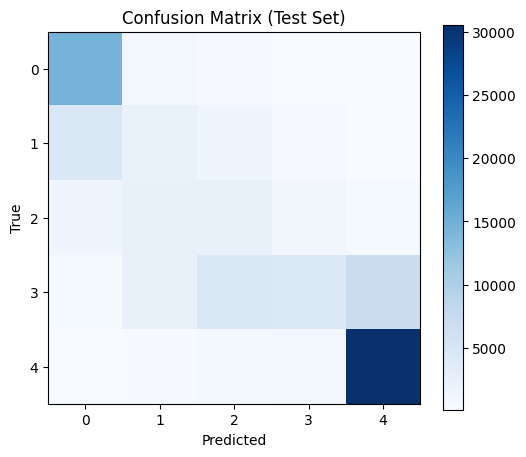

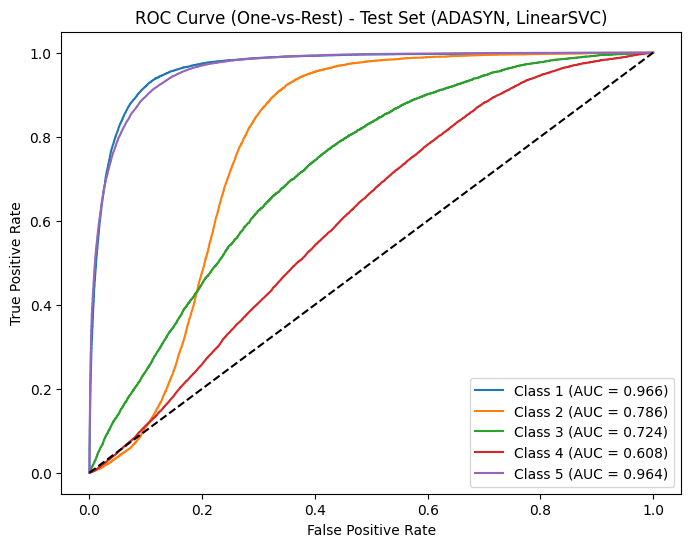

In [9]:
# =====================================
# 🧩 Block 6: Confusion Matrix & ROC Curve (ADASYN - LinearSVC)
# =====================================
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.show()

# --- 2) ROC Curve (ใช้ decision_function แทน predict_proba) ---
classes = model.classes_
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)

# ใช้ค่า decision function
y_score = model.decision_function(X_test)

# คำนวณ ROC / AUC
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- 3) พล็อตกราฟ ROC ---
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - Test Set (ADASYN, LinearSVC)')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# =====================================
# === Block 7: Save Model, AUC & ROC Points (Borderline-style)
# =====================================
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/ALL/'

# --- Save trained model ---
joblib.dump(model, base_path + 'svm_adasyn.pkl')
print(f"\n💾 Model saved as {base_path}svm_adasyn.pkl")

# --- Save AUC summary (Cross-validation + Test) ---
auc_df = pd.DataFrame({
    "Fold": list(range(1, 11)) + ["Test Set"],
    "AUC_ROC": auc_scores + [test_auc]
})
auc_df.to_csv(base_path + 'svm_adasyn_auc.csv', index=False)
print(f"💾 AUC-ROC values saved to {base_path}svm_adasyn_auc.csv")

# === ✅ คำนวณ ROC Curve ด้วย decision_function() หรือ predict_proba() ===
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd

# ใช้ classes จากโมเดลจริง
classes = model.classes_
n_classes = len(classes)

# แปลง y_test เป็น one-hot ตามลำดับ classes
y_test_bin = label_binarize(y_test, classes=classes)

# ✅ LinearSVC ไม่มี predict_proba ดังนั้นใช้ decision_function แทน
if hasattr(model, "predict_proba"):
    y_score = model.predict_proba(X_test)
else:
    y_score = model.decision_function(X_test)

# === คำนวณ ROC Curve ของแต่ละคลาส ===
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# (Optional) คำนวณ Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

# === Save ROC จุดต่อจุด เหมือน Borderline ===
roc_points = []
for i in range(n_classes):
    for fp, tp in zip(fpr[i], tpr[i]):
        roc_points.append({'Class': i, 'FPR': fp, 'TPR': tp})

roc_df = pd.DataFrame(roc_points)
roc_df.to_csv(base_path + 'svm_adasyn_roc_points.csv', index=False)
print(f"💾 ROC points saved to {base_path}svm_adasyn_roc_points.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

💾 Model saved as /content/drive/MyDrive/Senior_Project/roc/SVM_Roc/ALL/svm_adasyn.pkl
💾 AUC-ROC values saved to /content/drive/MyDrive/Senior_Project/roc/SVM_Roc/ALL/svm_adasyn_auc.csv
💾 ROC points saved to /content/drive/MyDrive/Senior_Project/roc/SVM_Roc/ALL/svm_adasyn_roc_points.csv
